# LSTM model with full feature set (no PCA)

**Using resampled features**

Author: Pete King

We now test a LSTM model using the full (complete) feature set, again using data resampled to a weekly frequency.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)

from helpers import data_prep as dp
from helpers import models

IMAGE_DIR = Path.cwd() / 'images'
DATA_DIR = Path.cwd().parent / 'data' / 'downsample' / 'W' / 'train-val-test'
TRAIN_DATA_FILE = DATA_DIR / 'train_BASE_DATA.csv'
VAL_DATA_FILE = DATA_DIR / 'val_BASE_DATA.csv'
TICKER = 'SPY'
SEQUENCE_LENGTH = 4  # No. observations in each input sequence to LSTM
BATCH_SIZE = 10  # For DataLoader

## I. Data Preparation

### Import and inspect financial data

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)
# Select data (X) and label (y) -- use all features
data_cols, _ = dp.get_X_y_cols(train_df, returns=True)
label_col = [TICKER + '_vol_target']
train_df[data_cols].head(SEQUENCE_LENGTH)

,one_month_yield_diff,three_month_yield_diff,six_month_yield_diff,one_year_yield_diff,two_year_yield_diff,five_year_yield_diff,ten_year_yield_diff,thirty_year_yield_diff,nominal_GDP_chg,real_GDP_chg,...,XLB_vol-h,XLE_vol-h,XLF_vol-h,XLI_vol-h,XLK_vol-h,XLP_vol-h,XLRE_vol-h,XLU_vol-h,XLV_vol-h,XLY_vol-h
date,,,,,,,,,,,,,,,,,,,,,
2015-10-11,0.01,0.00,0.01,0.02,0.04,0.06,0.05,0.04,0.001821,0.001845,...,0.015475,0.019629,0.010939,0.015204,0.009425,0.010602,0.000741,0.008933,0.013073,0.009286
2015-10-18,0.03,0.00,-0.01,-0.04,-0.03,0.00,-0.02,-0.02,0.001821,0.001845,...,0.005682,0.011585,0.011572,0.008683,0.005927,0.008371,0.009412,0.007745,0.012140,0.008375
2015-10-25,-0.05,-0.01,0.01,0.01,0.05,0.08,0.05,0.01,0.001821,0.001845,...,0.013638,0.013308,0.009617,0.012793,0.016336,0.009050,0.009390,0.009640,0.012871,0.006915
2015-11-01,0.00,0.06,0.07,0.09,0.09,0.11,0.09,0.06,0.001821,0.001845,...,0.007947,0.016180,0.012630,0.006200,0.008003,0.005718,0.003883,0.006223,0.009751,0.005900


In [3]:
val_df[label_col].head(SEQUENCE_LENGTH)

,SPY_vol_target
date,
2023-01-01,0.010604
2023-01-08,0.010161
2023-01-15,0.010400
2023-01-22,0.010328


### Scale Data

We represent each feature in a uniform range (0, 1).

In [4]:
scaler = MinMaxScaler()
# Take care to fit scaler only to training data
X_train = scaler.fit_transform(train_df[data_cols])
y_train = train_df[label_col].values
X_val = scaler.transform(val_df[data_cols])
y_val = val_df[label_col].values

## II. PyTorch Multivariate LSTM Model

### Create Datasets and DataLoaders

In [5]:
# Model Training
train_dataset = dp.FinancialDataset(
    X_train.astype(np.float32),
    y_train.astype(np.float32),
    sequence_length=SEQUENCE_LENGTH,
    target=True
)
train_dataloader = dp.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)
# Model Evaluation
val_dataset = dp.FinancialDataset(
    X_val.astype(np.float32),
    y_val.astype(np.float32),
    sequence_length=SEQUENCE_LENGTH,
    target=True
)
val_dataloader = dp.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

In [6]:
# Inspect first sample and label in training dataset
X_0, y_0 = train_dataset[0]
print(f'Shape of first training sample: {X_0.shape}')
print(f'Shape of first training label: {y_0.shape}')

Shape of first training sample: torch.Size([4, 87])
Shape of first training label: torch.Size([1])


In [7]:
# Inspect batch dimensions from dataloader
batched_data_0, batched_labels_0 = next(iter(train_dataloader))
print(f'Shape of first batch of data: {batched_data_0.shape}')
print(f'Shape of first batch of labels: {batched_labels_0.shape}')

Shape of first batch of data: torch.Size([10, 4, 87])
Shape of first batch of labels: torch.Size([10, 1])


In [8]:
print(y_0)

tensor([0.0075])


### Instantiate and train LSTM model

Here we increase the number of neurons in the hidden layer to allow the model to capture more complex relationships in the input data.  This could lead to overfitting if we set it too high.

In [9]:
# Define LSTM parameters
input_size = len(data_cols)  # Number of features in data (x)
hidden_size = 64  # Number of 'neurons' (features) in each hidden layer
num_layers = 1  # Number of LSTM layers in the model stack
batch_first = True  # Determines order of dimensions for input/output tensors
bidirectional = False  # If True, becomes a bidirectional LSTM
proj_size = 0  # If > 0, will use LSTM with projections of corresponding size

# Define variables for LSTM input/output tensor dimensions IAW PyTorch docs
N = BATCH_SIZE  # Batch size
L = SEQUENCE_LENGTH  # Sequence length (no. timestamps in rolling window)
D = int(bidirectional) + 1   # D = 1 (not birectional) or 2 (bidirectional)
H_in = input_size
H_cell = hidden_size
H_out = (proj_size if proj_size > 0 else H_in)

# Define number of dimensions in target labels (y)
label_size = len(label_col)

In [10]:
# Set an accelerator device (e.g., CUDA) if available.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = 'cpu'

print(f'Device: {device}')

Device: cpu


In [11]:
# Instantiate LSTM and assign to device
model = models.FinancialLSTM(
    input_size=input_size,
    label_size=label_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    batch_first=batch_first,
    bidirectional=bidirectional,
    proj_size=proj_size
).to(device)
print(model)

FinancialLSTM(
  (lstm): LSTM(87, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


#### Loss function and Optimizer


In [12]:
# Define loss function and optimizer
# For multivariate loss, set parameter reduction='none'
loss_fn = torch.nn.L1Loss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters())

In [13]:
# Train and evaluate model
epochs = 100
print(f'Training model over {epochs} epochs...')
for epoch in range(epochs):
    loss_trn = models.train_model(train_dataloader, model, loss_fn, optimizer)
    if (epoch + 1) % 10 == 0:
        loss_val, preds = models.evaluate_model(val_dataloader, model, loss_fn)
        print(f'Epoch {epoch + 1}')
        print(f'Training loss:   {loss_trn}')
        print(f'Validation loss: {loss_val}')

Training model over 100 epochs...
Epoch 10
Training loss:   0.0030922943260520697
Validation loss: 0.0027252391446381807
Epoch 20
Training loss:   0.007861140184104443
Validation loss: 0.00991577934473753
Epoch 30
Training loss:   0.001098022679798305
Validation loss: 0.0013913351576775312
Epoch 40
Training loss:   0.0008372745360247791
Validation loss: 0.0036350886803120375
Epoch 50
Training loss:   0.0009996967855840921
Validation loss: 0.002127875806763768
Epoch 60
Training loss:   0.0017288606613874435
Validation loss: 0.0035916713532060385
Epoch 70
Training loss:   0.0012266685953363776
Validation loss: 0.0013186039868742228
Epoch 80
Training loss:   0.000845684960950166
Validation loss: 0.000988147919997573
Epoch 90
Training loss:   0.0012859220150858164
Validation loss: 0.003293615533038974
Epoch 100
Training loss:   0.0007996757049113512
Validation loss: 0.0009929018560796976


## III. Analyze Results

### Plot of predictions vs labels (final epoch)


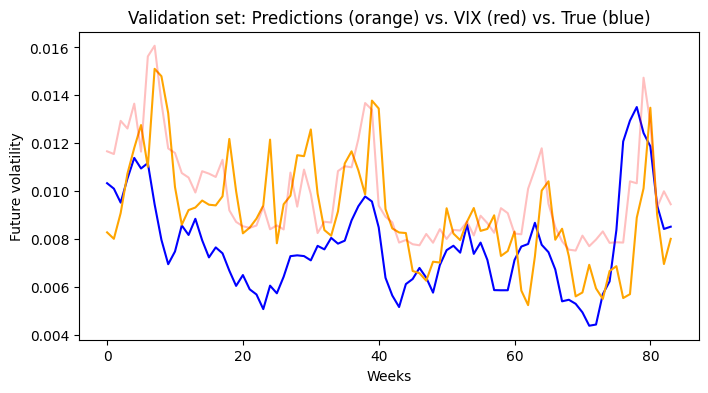

In [14]:
x = range(len(val_dataset))
labels = [val_dataset[i][1]for i in range(len(x))]
# The VIX estimates annualized volatility for the next 30 days
vix = val_df['^VIX'].values[SEQUENCE_LENGTH:] / np.sqrt(252) / 100

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()
ax.set_title('Validation set: Predictions (orange) vs. VIX (red) vs. True (blue)')
ax.set_ylabel('Future volatility')
ax.set_xlabel('Weeks')
ax.plot(x, labels, color='blue')
ax.plot(x, preds, color='orange')
ax.plot(x, vix, color='red', alpha=0.25)
fig.savefig(IMAGE_DIR / 'W-LSTM-full')

The full set of features appears to have introduced additional noise -- predictions appear more erratic than in the case with limited input.

In [15]:
metrics = {
    'MAE': mean_absolute_error,
    'R2': r2_score,
}
# Out-of-sample R-squared compares model performance to baseline (VIX)
r2_oos = 1 - (
    mean_absolute_error(labels, preds)
    / mean_absolute_error(labels, vix)
)
# Display results
for metric, scorer in metrics.items():
    print(f'Model {metric}: {scorer(labels, preds):.5f}')
    print(f'VIX {metric}:   {scorer(labels, vix):.5f}')
    print('---')
print(f'Model R2-OOS: {r2_oos:.2f}')

Model MAE: 0.00220
VIX MAE:   0.00236
---
Model R2: -1.08064
VIX R2:   -0.86598
---
Model R2-OOS: 0.07


The out-of-sample R-squared very close to zero indicates that with the full feature set, our model performed only slightly better than the baseline model.